# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
%load_ext autoreload
%autoreload 2
from src.utils import print_images, stratified_split, set_seed, get_stratified_sample
from src.PCA import standardize_data, pca_fit, pca_transform, pca_inverse_transform
from src.AE import AE, Trainer, get_dataloaders
from src.BVAE import BVAE, BVAETrainer
from src.clustering import k_means, GMM, silhouette_score, tsne, find_elbow_point, align_clusters_to_classes, plot_cluster_quality

RANDOM_SEED = 1973

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## EDA

In [27]:
df = pd.read_csv("data/raw/fashion_mnist_subset.csv")
y = df["label"]
X = df.drop(columns=["label"])

# Verificar shape
print("X shape:", X.shape)  
print("y shape:", y.shape)
print("Labels:", np.unique(y))

np.save("data/raw/X_images.npy", X)
np.save("data/raw/y_labels.npy", y)

X shape: (25000, 784)
y shape: (25000,)
Labels: [0 1 2 3 4 5 6 7 8 9]


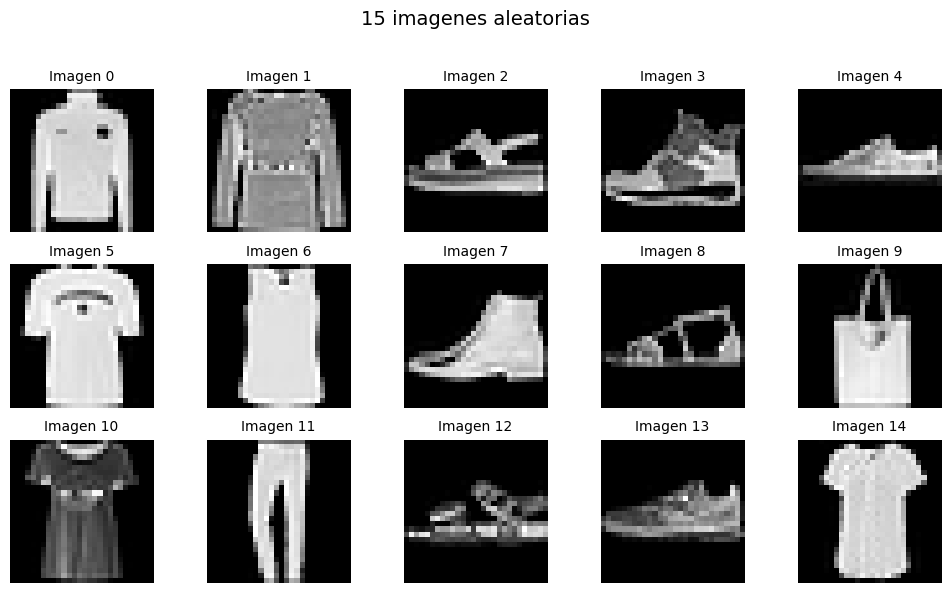

In [28]:
X = np.load("data/raw/X_images.npy")
y = np.load("data/raw/y_labels.npy")
N = 15

print_images(N, X, f"{N} imagenes aleatorias",RANDOM_SEED)

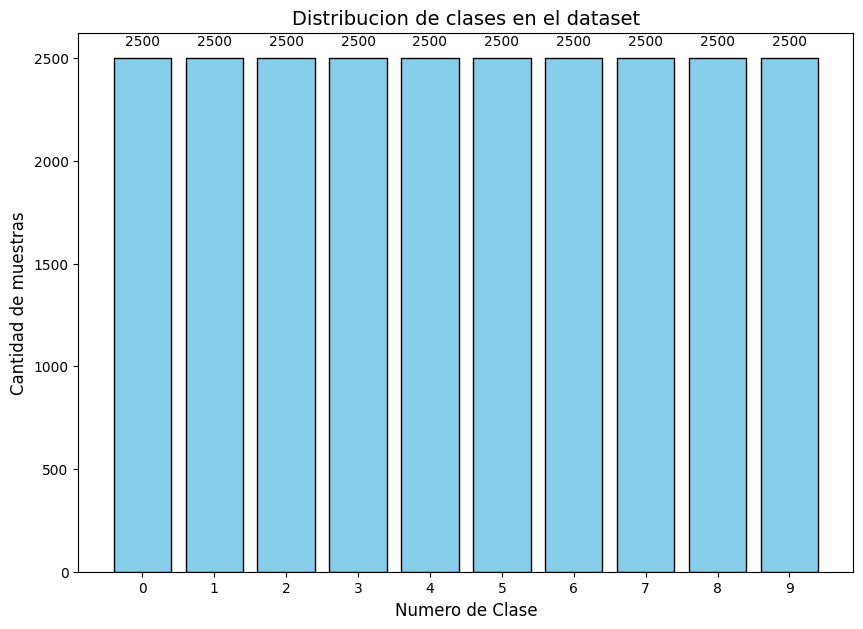

In [29]:
# Grafico de distribucion de clases

clases, conteos = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 7))

bars = plt.bar(clases, conteos, color='skyblue', edgecolor='black')

plt.title('Distribucion de clases en el dataset', fontsize=14)
plt.xlabel('Numero de Clase', fontsize=12)
plt.ylabel('Cantidad de muestras', fontsize=12)

plt.xticks(clases)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), 
             ha='center', va='bottom', fontsize=10)

plt.show()

Se observa que el conjunto de datos se encuentra perfectamente balanceado, contando con exactamente 2500 muestras para cada una de las 10 clases. Esta distribución uniforme es ideal, ya que evita la necesidad de aplicar técnicas de remuestreo o de lidiar con sesgos hacia clases mayoritarias durante el modelado.

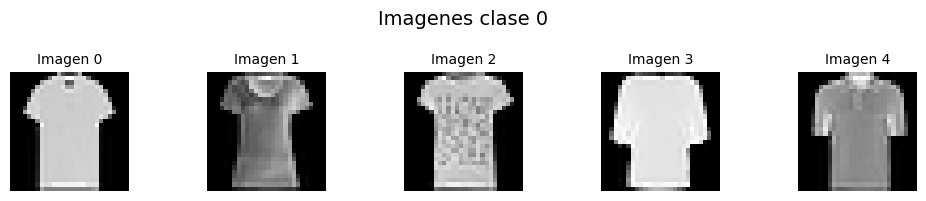

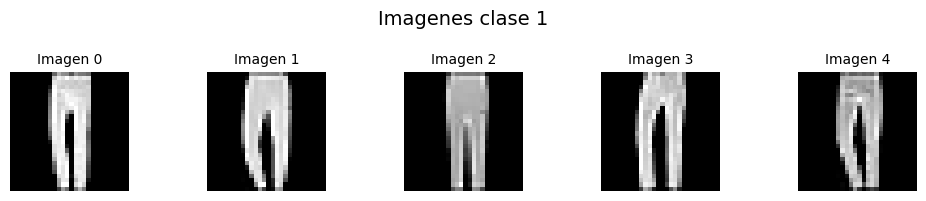

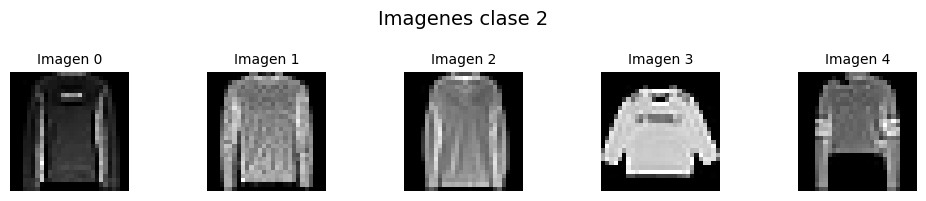

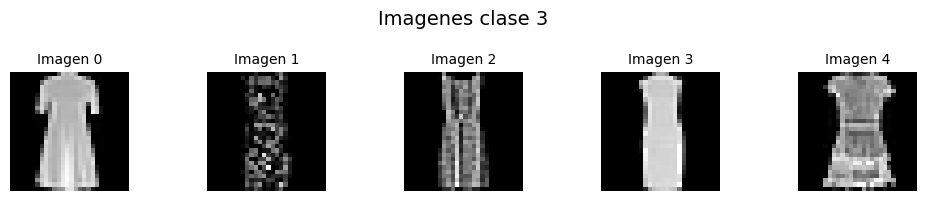

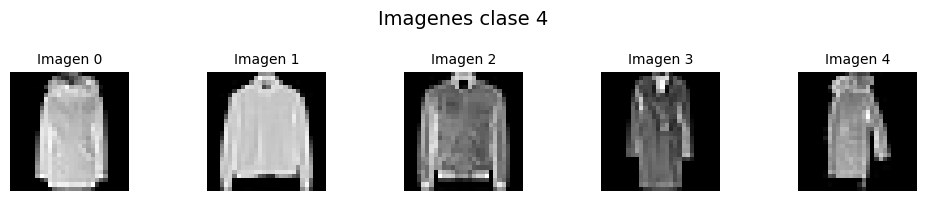

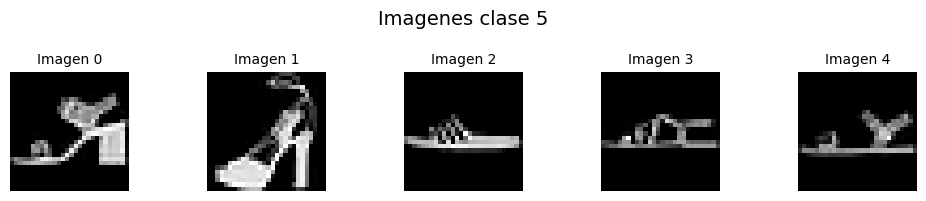

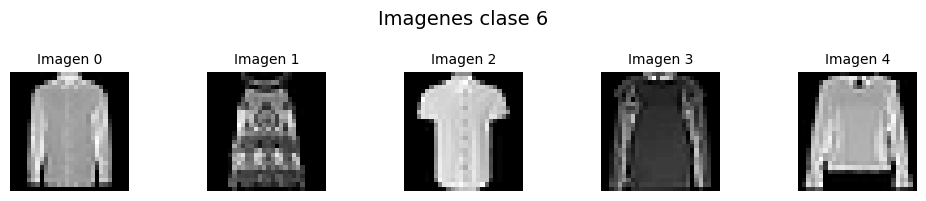

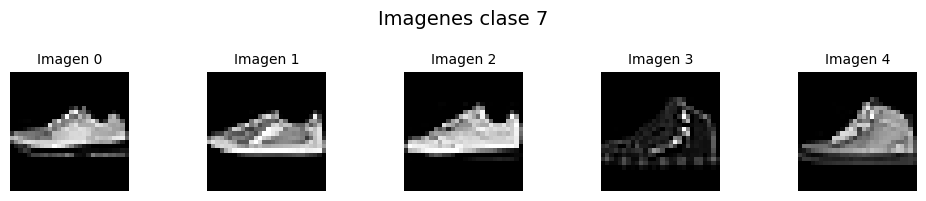

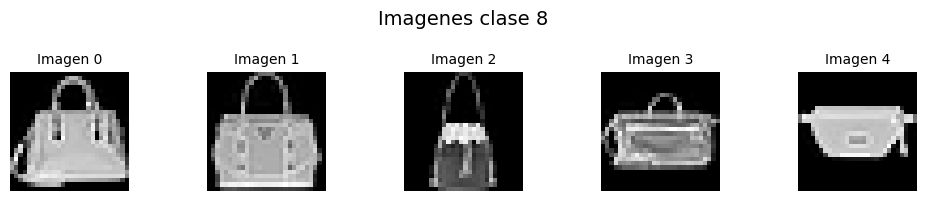

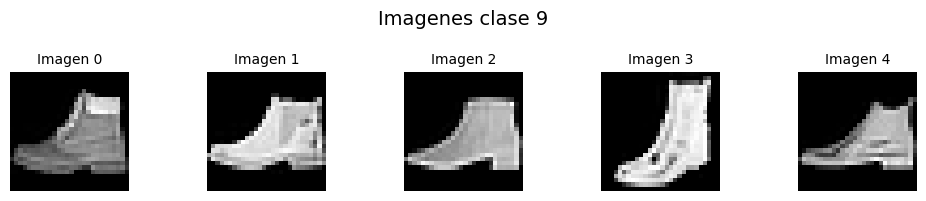

In [30]:
for i in np.unique(y):
    class_images = X[y == i]
    print_images(
        5,
        class_images,
        random_seed=RANDOM_SEED+i,
        title=f"Imagenes clase {i}"
    )

Se observa una notable variabilidad intra-clase: dentro de una misma clase existen diferencias evidentes en diseño, textura, grosor y forma. Esta diversidad subraya la importancia de utilizar técnicas robustas de reducción de dimensionalidad (como PCA o Autoencoders) que logren extraer características latentes significativas, en lugar de depender únicamente de las similitudes a nivel de píxel, para luego faciliar el clustering.

In [31]:
# Hago un split 80/20 manteniendo la misma proporcion de cada clase en train y validation

X_train, X_val, y_train, y_val = stratified_split(X, y, 0.8)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")

for label in np.unique(y):
    train_count = np.sum(y_train == label)
    val_count = np.sum(y_val == label)

    print(
        f"Clase {label}: "
        f"train={train_count}/{len(y_train)} ({train_count / len(y_train):.1%}), "
        f"val={val_count}/{len(y_val)} ({val_count / len(y_val):.1%})"
    )

np.save("data/preprocessed/X_train.npy", X_train)
np.save("data/preprocessed/X_val.npy", X_val)
np.save("data/preprocessed/y_train.npy", y_train)
np.save("data/preprocessed/y_val.npy", y_val)

Train size: 20000
Val size: 5000
Clase 0: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 1: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 2: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 3: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 4: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 5: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 6: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 7: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 8: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 9: train=2000/20000 (10.0%), val=500/5000 (10.0%)


## Reducción de dimensionalidad

### PCA

In [32]:
# Estandarizo losa datos de train
X_train_std, mean_train, std_train = standardize_data(X_train)

# fiteo y aplico PCA a los datos de train
components_train, variance_ratio = pca_fit(X_train_std)
n_comp = 100 # Tomo un numero de componentes arbitrario para checkear que funcione
X_train_pca = pca_transform(X_train_std, components_train, n_comp)

# Estandarizo los datos de validation usando la media y std del train
X_val_std, _, _ = standardize_data(X_val, mean=mean_train, std=std_train)
X_val_pca = pca_transform(X_val_std, components_train, n_comp)

print("Verificacion de Dimensiones")

# Chequeo de los datos originales
print(f"Dimensiones de X_train original: {X_train.shape}")
print(f"Dimensiones de X_val original: {X_val.shape}")

# Chequeo de los datos estandarizados
print(f"Dimensiones de X_train_std: {X_train_std.shape}")
print(f"Dimensiones de X_val_std: {X_val_std.shape}")

# Chequeo de los componentes obtenidos por SVD
print(f"Dimensiones de matriz Vt: {components_train.shape}")

# Chequeo de los datos reducidos
print(f"Dimensiones de X_train_pca: {X_train_pca.shape}")
print(f"Dimensiones de X_val_pca: {X_val_pca.shape}")

Verificacion de Dimensiones
Dimensiones de X_train original: (20000, 784)
Dimensiones de X_val original: (5000, 784)
Dimensiones de X_train_std: (20000, 784)
Dimensiones de X_val_std: (5000, 784)
Dimensiones de matriz Vt: (784, 784)
Dimensiones de X_train_pca: (20000, 100)
Dimensiones de X_val_pca: (5000, 100)


Numero de componentes necesarios para explicar el 90% de la varianza: 134


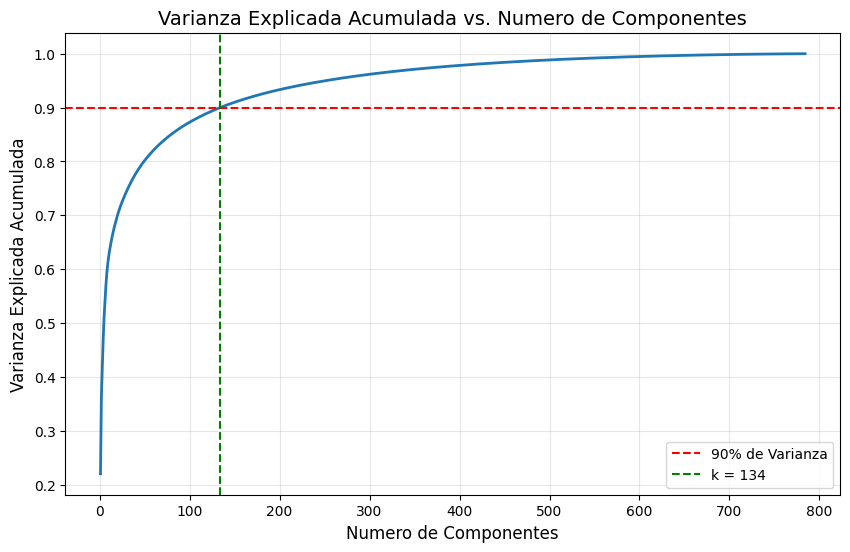

In [33]:
# varianza acumulada de los componentes
cumulative_variance = np.cumsum(variance_ratio)

# busco el k para tener el 90% de varianza explicada
k_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Numero de componentes necesarios para explicar el 90% de la varianza: {k_90}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de Varianza')
plt.axvline(x=k_90, color='g', linestyle='--', label=f'k = {k_90}')
plt.title('Varianza Explicada Acumulada vs. Numero de Componentes', fontsize=14)
plt.xlabel('Numero de Componentes', fontsize=12)
plt.ylabel('Varianza Explicada Acumulada', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

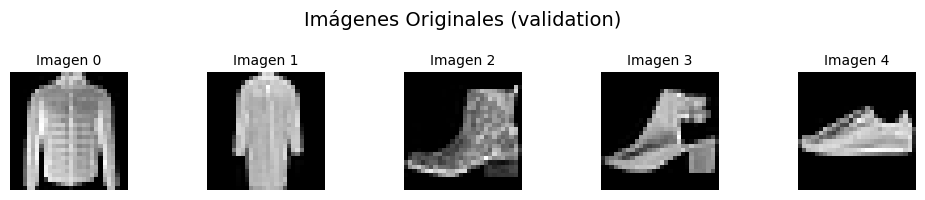

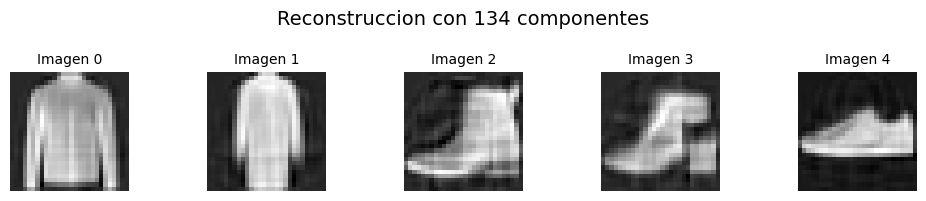

In [34]:
# transformo los datos de validation usando los k_90 componentes necesarios para explicar el 90% de la varianza
X_val_pca_90 = pca_transform(X_val_std, components_train, k_90)

# reconstruyo las imagenes a partir de esos k_90 componentes
X_val_reconstructed = pca_inverse_transform(X_val_pca_90, components_train, k_90, mean_train, std_train)

print_images(5, X_val, random_seed=RANDOM_SEED, title="Imágenes Originales (validation)")
print_images(5, X_val_reconstructed, random_seed=RANDOM_SEED, title=f"Reconstruccion con {k_90} componentes")

El análisis de la varianza explicada acumulada indicó que se requieren 134 componentes principales para alcanzar el umbral de retención del 90% de la información original del dataset. Al proyectar las muestras sobre este subespacio latente reducido y proceder con su reconstrucción, se observa que la transformación preserva con éxito la estructura general, la simetría y la silueta global de las distintas clases de prendas y calzados. No obstante, esta compresión (que reduce la dimensionalidad de 784 píxeles a 134 componentes) conlleva una pérdida natural de información espacial de alta frecuencia. Visualmente, esto se traduce en que los detalles finos, las texturas complejas y los bordes definidos se suavizan, produciendo un efecto de difuminado (en las prendas y en el fondo)

### Autoencoder deterministico (AE)

Early Stopping en epoch 262!
--------------------------------------------------
Entrenamiento finalizado.
Validation Loss final retenida: 0.1018
--------------------------------------------------


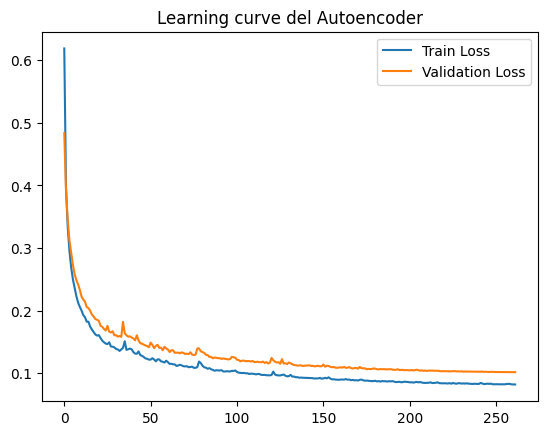

In [158]:
set_seed(RANDOM_SEED)

train_loader, val_loader = get_dataloaders(X_train_std, y_train, X_val_std, y_val, batch_size=512)
input_dimension = X_train_std.shape[1] 
latent_dimension = k_90 # Uso el mismo numero de componentes que para PCA para comparar resultados

autoencoder = AE(input_dim=input_dimension, latent_dim=latent_dimension, dropout_p=0.01)

trainer = Trainer(autoencoder, train_loader, val_loader, lr=0.001)
loss_history, val_loss_history = trainer.train(early_stopping=True, patience=30, epochs=300)

mejor_val_loss = min(val_loss_history)

print("-" * 50)
print(f"Entrenamiento finalizado.")
print(f"Validation Loss final retenida: {mejor_val_loss:.4f}")
print("-" * 50)

# Grafico de la learning curve del autoencoder
plt.plot(loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.legend()
plt.title('Learning curve del Autoencoder')
plt.show()

La learning curve muetsra un proceso de optimización estable y convergente. A lo largo de las 262 épocas, se observa un descenso suave y continuo tanto en la Train Loss como en la Validation Loss, manteniendo una brecha mínima entre ambas métricas(no hya overfitting). El mecanismo de Early Stopping actuó de manera óptima al detener el entrenamiento una vez alcanzada la convergencia asintótica, logrando retener una Validation Loss mínima de 0.1018. En conjunto, este comportamiento confirma que la arquitectura es robusta y logra comprimir eficientemente las características latentes del dataset, brindando una buena representación para la posterior etapa de clustering.

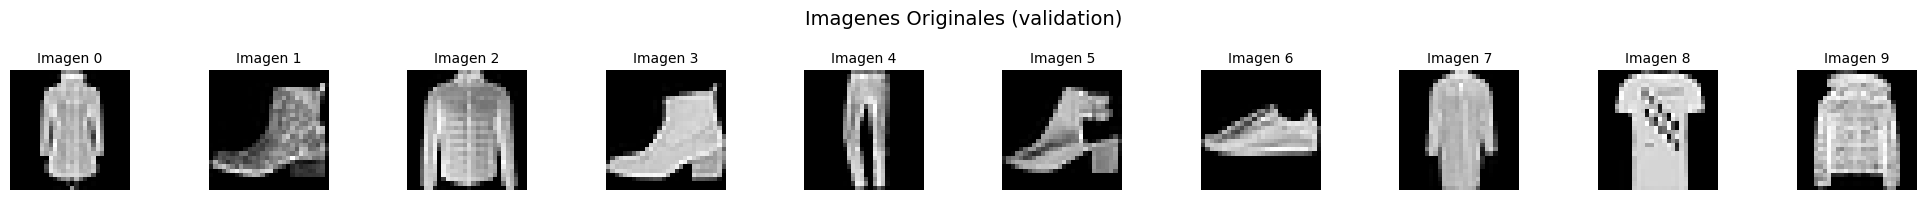

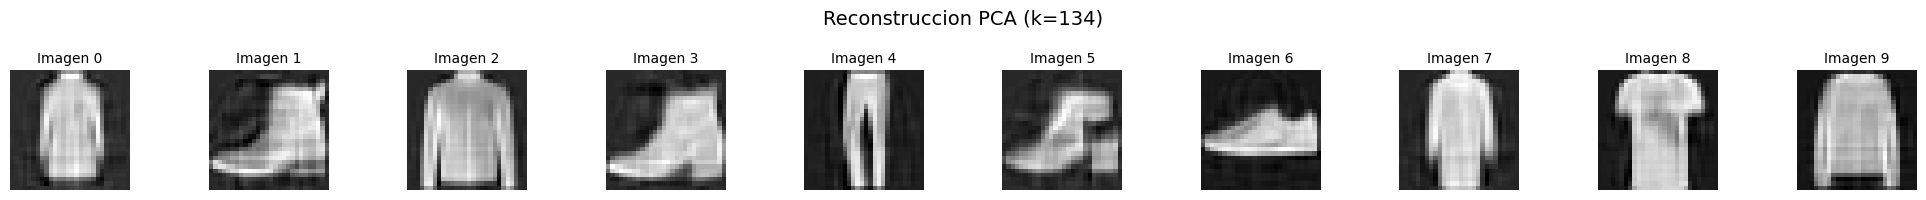

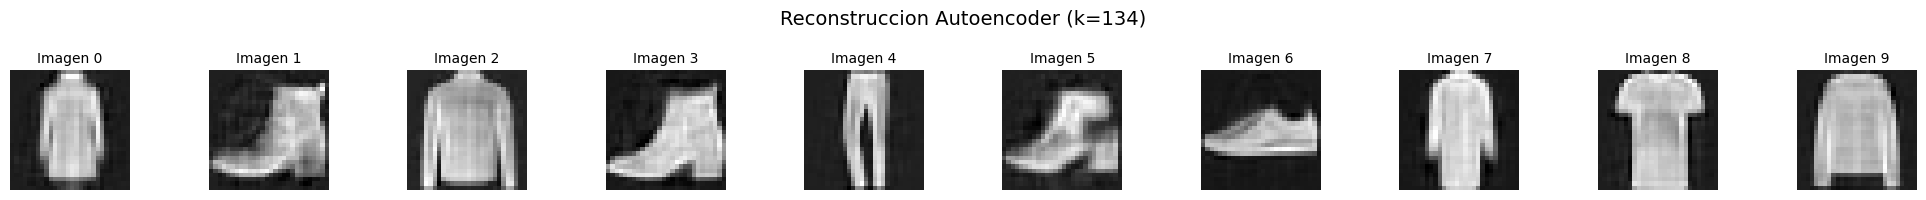

In [67]:
np.random.seed(RANDOM_SEED) 
indices = np.random.choice(len(X_val), 10, replace=False)

# muestras aleaotrias de validation para comparar las reconstrucciones
X_sample_std = X_val_std[indices]
X_sample_original = X_val[indices]

# reconstruccion con PCA
X_sample_pca_latente = pca_transform(X_sample_std, components_train, k_90)
X_sample_pca_rec = pca_inverse_transform(X_sample_pca_latente, components_train, k_90, mean_train, std_train)

# reconstruccion con Autoencoder
X_sample_ae_std_rec = autoencoder.reconstruct(X_sample_std)
X_sample_ae_rec = (X_sample_ae_std_rec * std_train) + mean_train

print_images(10, X_sample_original, random_seed=RANDOM_SEED, title="Imagenes Originales (validation)", cols=10)
print_images(10, X_sample_pca_rec, random_seed=RANDOM_SEED, title=f"Reconstruccion PCA (k={k_90})", cols=10)
print_images(10, X_sample_ae_rec, random_seed=RANDOM_SEED, title=f"Reconstruccion Autoencoder (k={latent_dimension})", cols=10)


Al evaluar las reconstrucciones generadas por ambos modelos sobre un mismo subconjunto de validation y manteniendo una dimensión latente idéntica (k=134), se ve que tanto PCA como el Autoencoder logran preservar con éxito la estructura general de las prendas originales. Sin embargo, la naturaleza de cada algoritmo introduce diferencias visuales notables. PCA, al limitarse a proyecciones lineales, genera reconstrucciones que presentan un difuminado generalizado y la aparición de ruido residual en los píxeles del fondo oscuro. En contraste, el Autoencoder, gracias a la capacidad de sus funciones de activación para modelar relaciones no lineales, produce imágenes con fondos notablemente más limpios y bordes ligeramente más definidos (visible, por ejemplo, en la imagen 3). Si bien ambos métodos comparten la limitación de perder información de alta frecuencia (como los estampados complejos de la Imagen 8), el AE demuestra ser mejor al aislar mejor el objeto de interés y mitigar el ruido de fondo.

### Beta VAE

Early Stopping en epoch 265!
--------------------------------------------------
Entrenamiento del β-VAE finalizado.
Validation Total Loss final: 0.2312
--------------------------------------------------


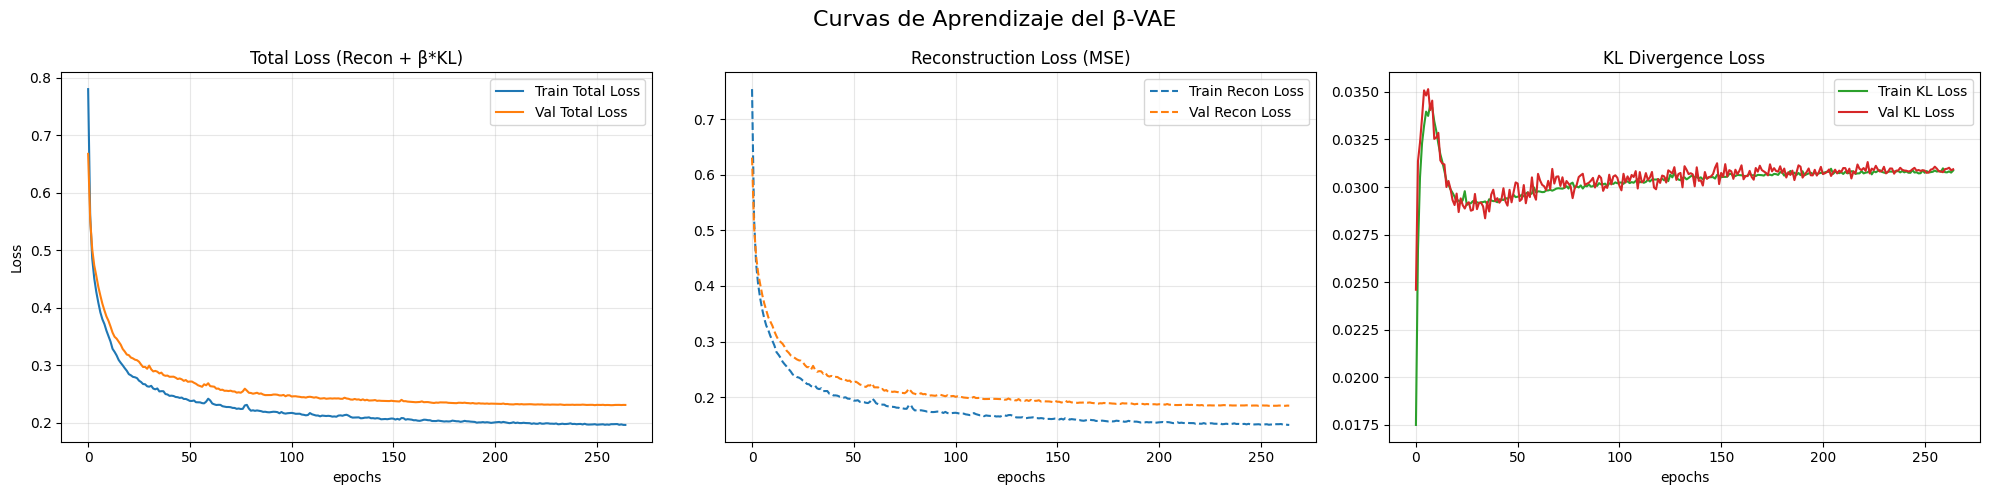

In [159]:
set_seed(RANDOM_SEED)

train_loader, val_loader = get_dataloaders(X_train_std, y_train, X_val_std, y_val, batch_size=512)
input_dimension = X_train_std.shape[1] 
latent_dimension = k_90 # Uso el mismo numero de componentes que para PCA para comparar resultados

bvae = BVAE(input_dim=input_dimension, latent_dim=latent_dimension, dropout_p=0.01)

trainer = BVAETrainer(bvae, train_loader, val_loader, lr=0.001, beta=1.5)
history = trainer.train(early_stopping=True, patience=30, epochs=300)

print("-" * 50)
print("Entrenamiento del β-VAE finalizado.")
print(f"Validation Total Loss final: {history['val_total'][-1]:.4f}")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Curvas de Aprendizaje del β-VAE', fontsize=16)

# Loss Total
axes[0].plot(history['train_total'], label='Train Total Loss', color='tab:blue')
axes[0].plot(history['val_total'], label='Val Total Loss', color='tab:orange')
axes[0].set_title('Total Loss (Recon + β*KL)')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss de Reconstrucción (MSE)
axes[1].plot(history['train_recon'], label='Train Recon Loss', color='tab:blue', linestyle='--')
axes[1].plot(history['val_recon'], label='Val Recon Loss', color='tab:orange', linestyle='--')
axes[1].set_title('Reconstruction Loss (MSE)')
axes[1].set_xlabel('epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Divergencia KL
axes[2].plot(history['train_kl'], label='Train KL Loss', color='tab:green')
axes[2].plot(history['val_kl'], label='Val KL Loss', color='tab:red')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('epochs')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas de aprendizaje muestran un entrenamiento estable y convergente, con el early stopping activándose en la época 265. La loss total desciende desde ~0.78 hasta ~0.23 en validation, y la brecha con train (~0.21) es pequeña y constante, lo que indica ausencia de overfitting. La loss de reconstrucción converge hacia ~0.19 en validation y ~0.17 en train. La diferencia con el error del AE deterministico (error ~90% mayor) es esperable debido al termino de regularizacion $\beta \cdot D_{KL}$ que fuerza al encoder a comprimir la información de forma que el espacio latente se aproxime al prior $\mathcal{N}(0, I)$, sacrificando algo de fidelidad de reconstrucción a cambio de obtener un espacio latente más estructurado y continuo. El comportamiento más característico del VAE se observa en la divergencia KL que arranca baja (~0.018), sube rápidamente hasta ~0.035 durante las primeras épocas a medida que el encoder aprende a codificar información, y luego se estabiliza en alrededor de 0.031 por el resto del entrenamiento. Este equilibrio refleja que el modelo encontró el balance entre reconstruir bien y mantenerse cercano al prior, efecto amplificado por el $\beta=1.5$ elegido, que penaliza las desviaciones del prior más que un VAE estándar y favorece un espacio latente más regularizado.

#### Comparacion de reconstrucciones

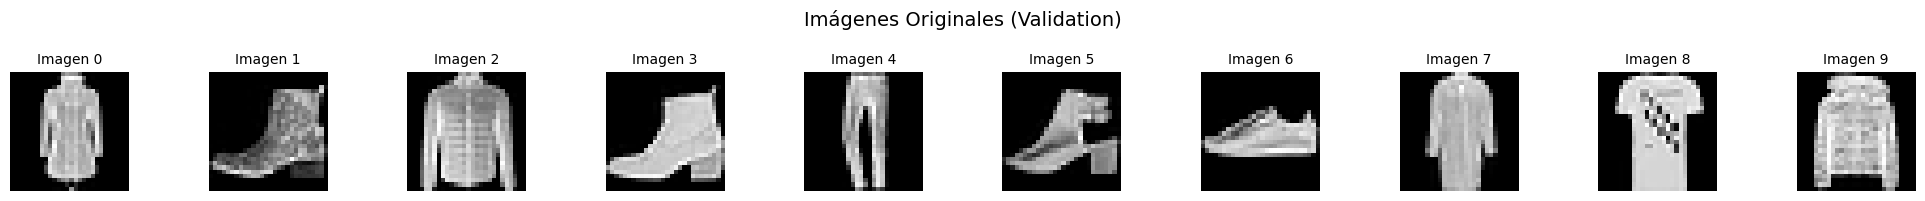

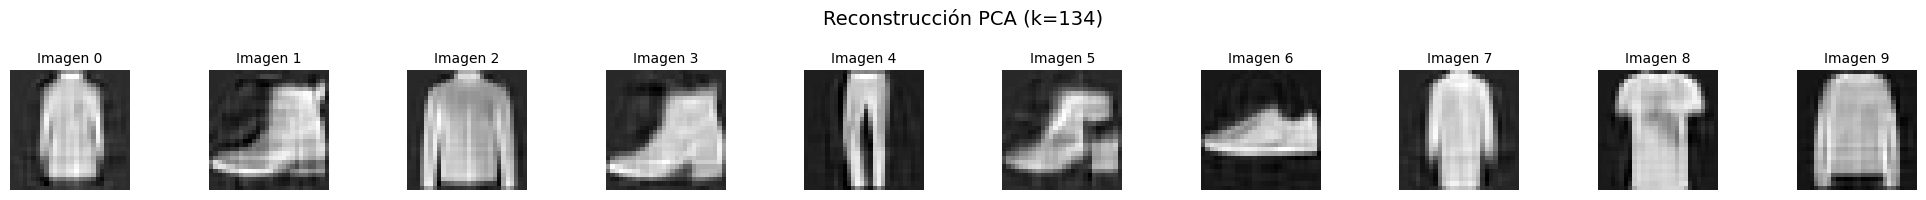

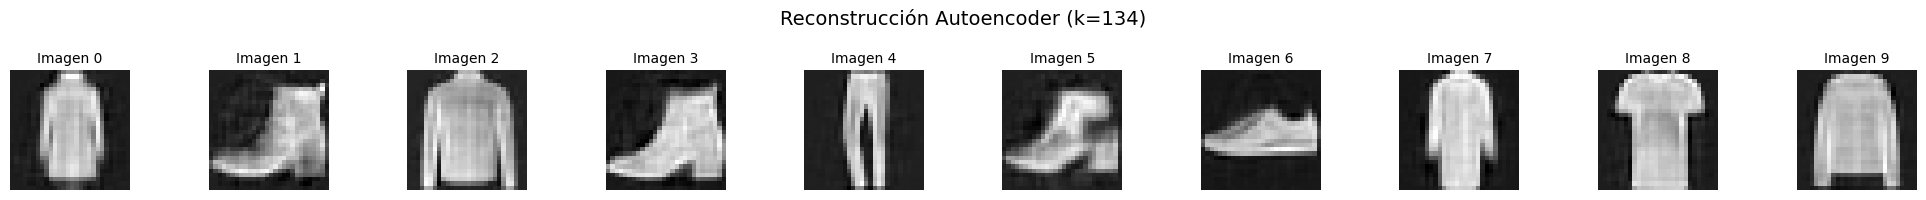

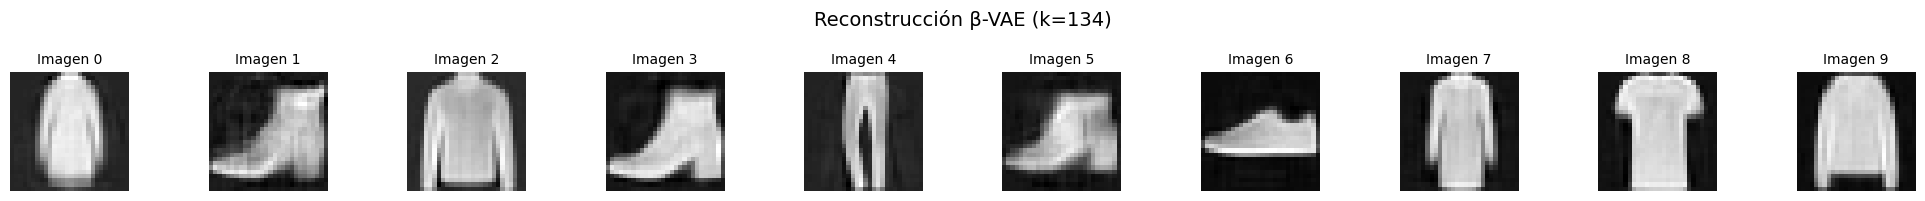

In [160]:
np.random.seed(RANDOM_SEED) 
indices = np.random.choice(len(X_val), 10, replace=False)

# Muestras aleatorias de validation
X_sample_std = X_val_std[indices]
X_sample_original = X_val[indices]

# 2. Reconstruccion con PCA
X_sample_pca_latente = pca_transform(X_sample_std, components_train, k_90)
X_sample_pca_rec = pca_inverse_transform(X_sample_pca_latente, components_train, k_90, mean_train, std_train)

# 3. Reconstruccion con Autoencoder Determinístico (AE)
X_sample_ae_std_rec = autoencoder.reconstruct(X_sample_std)
X_sample_ae_rec = (X_sample_ae_std_rec * std_train) + mean_train

# 4. Reconstruccion con β-VAE
X_sample_bvae_std_rec = bvae.reconstruct(X_sample_std)
X_sample_bvae_rec = (X_sample_bvae_std_rec * std_train) + mean_train

# --- Visualización ---
print_images(10, X_sample_original, random_seed=RANDOM_SEED, title="Imágenes Originales (Validation)", cols=10)
print_images(10, X_sample_pca_rec, random_seed=RANDOM_SEED, title=f"Reconstrucción PCA (k={k_90})", cols=10)
print_images(10, X_sample_ae_rec, random_seed=RANDOM_SEED, title=f"Reconstrucción Autoencoder (k={latent_dimension})", cols=10)
print_images(10, X_sample_bvae_rec, random_seed=RANDOM_SEED, title=f"Reconstrucción β-VAE (k={latent_dimension})", cols=10)

En contraste, las reconstrucciones generadas por el $\beta$-VAE se presentan característicamente más "suaves" o difuminadas, perdiendo por completo detalles de alta frecuencia (como el estampado de la Imagen 8). Es crucial destacar que esta pérdida de agudeza visual frente al AE no representa un bajo rendimiento, sino que es el efecto directo de la regularización probabilística. Al forzar a las representaciones a asemejarse a una normal estándar $\mathcal{N}(0, I)$ mediante la penalización de la divergencia KL, el $\beta$-VAE prioriza aprender conceptos estructurales y construir un espacio latente continuo e interpolable, sacrificando la memorización de píxeles característica de los métodos determinísticos.

#### Experimento 1

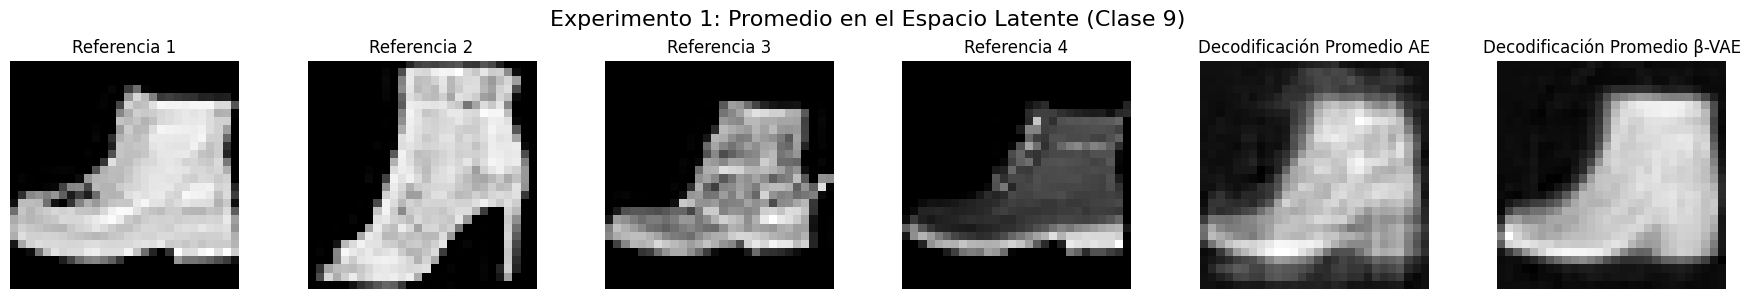

In [164]:
set_seed(RANDOM_SEED)
CLASE_OBJETIVO = 9

indices_clase = np.where(y_val == CLASE_OBJETIVO)[0]
indices_seleccionados = np.random.choice(indices_clase, 4, replace=False)

X_ref_original = X_val[indices_seleccionados]
X_ref_std = X_val_std[indices_seleccionados]

# Autoencoder 
z_ae = autoencoder.get_latent_features(X_ref_std)
z_ae_promedio = np.mean(z_ae, axis=0, keepdims=True)

# β-VAE (obtenemos las medias mu de las 4 imágenes)
z_bvae = bvae.get_latent_features(X_ref_std)
z_bvae_promedio = np.mean(z_bvae, axis=0, keepdims=True)

# decode de los promedios
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.eval()
bvae.eval()

with torch.no_grad():
    z_ae_tensor = torch.tensor(z_ae_promedio, dtype=torch.float32).to(device)
    rec_ae_std = autoencoder.decoder(z_ae_tensor).cpu().numpy()
    
    z_bvae_tensor = torch.tensor(z_bvae_promedio, dtype=torch.float32).to(device)
    rec_bvae_std = bvae.decoder(z_bvae_tensor).cpu().numpy()

# desestandarizar las reconstrucciones para poder graficar
rec_ae = (rec_ae_std * std_train) + mean_train
rec_bvae = (rec_bvae_std * std_train) + mean_train

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle(f'Experimento 1: Promedio en el Espacio Latente (Clase {CLASE_OBJETIVO})', fontsize=16)

# imagenes originales de referencia
for i in range(4):
    axes[i].imshow(X_ref_original[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Referencia {i+1}')
    axes[i].axis('off')

# reconstruccion del promedio AE
axes[4].imshow(rec_ae.reshape(28, 28), cmap='gray')
axes[4].set_title('Decodificación Promedio AE')
axes[4].axis('off')

# reconstruccion del promedio β-VAE
axes[5].imshow(rec_bvae.reshape(28, 28), cmap='gray')
axes[5].set_title('Decodificación Promedio β-VAE')
axes[5].axis('off')

plt.tight_layout()
plt.show()

La visualización confirma la superioridad topológica de los modelos generativos probabilísticos frente a los enfoques tradicionales. Al decodificar el vector promedio en el Autoencoder determinístico, la imagen resultante se ve muy difusa. Esto se debe a que el AE mapea cada entrada a puntos fijos, aislados y discretos sin imponer ninguna estructura global, lo que hace que el promedio caiga en una región vacía del espacio latente que el decoder nunca aprendió a interpretar. Por el contrario, el $\beta$-VAE logra decodificar el promedio con mucha mayor precisión, generando una bota completamente coherente y verosímil que fusiona de manera natural los atributos de las cuatro referencias. Este comportamiento radica en que el $\beta$-VAE modela sus representaciones como distribuciones latentes probabilísticas. Al estar fuertemente regularizado, garantiza un espacio latente continuo, suave y denso, asegurando que cualquier interpolación geométrica caiga sobre una región válida que el decoder puede reconstruir con facilidad.

#### Experimento 2

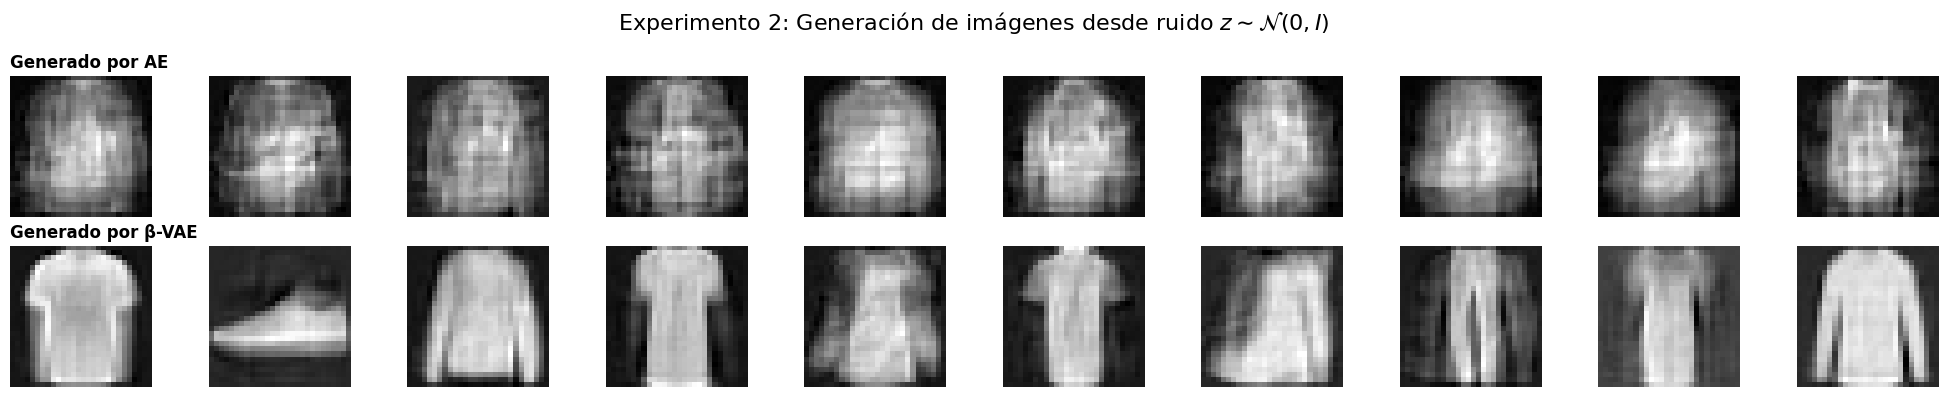

In [ ]:
set_seed(RANDOM_SEED)
n_samples = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Muestrear vectores z desde una distribución Normal Estándar N(0, I)
z_aleatorios = torch.randn(n_samples, latent_dimension).to(device)

# Decodificar los vectores aleatorios con ambos modelos
autoencoder.eval()
bvae.eval()

with torch.no_grad():
    rec_ae_std = autoencoder.decoder(z_aleatorios).cpu().numpy()
    rec_bvae_std = bvae.decoder(z_aleatorios).cpu().numpy()

# Desestandarizar para poder graficar
rec_ae_generadas = (rec_ae_std * std_train) + mean_train
rec_bvae_generadas = (rec_bvae_std * std_train) + mean_train

fig, axes = plt.subplots(2, n_samples, figsize=(20, 4))
fig.suptitle('Experimento 2: Generación de imágenes desde ruido $z \sim \mathcal{N}(0, I)$', fontsize=16)

for i in range(n_samples):
    # Autoencoder Deterministico
    axes[0, i].imshow(rec_ae_generadas[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Generado por AE', loc='left', fontweight='bold')
        
    # β-VAE
    axes[1, i].imshow(rec_bvae_generadas[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Generado por β-VAE', loc='left', fontweight='bold')

plt.tight_layout()
plt.show()

La visualización de las imágenes generadas a partir de ruido aleatorio evidencia la diferencia fundamental entre ambos enfoques. Al decodificar vectores muestreados de una distribución normal estándar, el Autoencoder determinístico (AE) fracasa en la tarea generativa, produciendo únicamente formas difusas sin sentido. Esto demuestra que su espacio latente carece de regularización global. Al no estar restringido, los vectores aleatorios suelen caer en zonas que el decoder no sabe cómo interpretar. Por otro lado, el $\beta$-VAE logra sintetizar datos completamente nuevos, variados y estructuralmente coherentes (como pantalones, remeras y calzado). Este éxito valida la inclusión de la penalización KL durante el entrenamiento, la cual forzó a la distribución marginal del espacio latente a organizarse siguiendo la forma $\mathcal{N}(0, I)$. Como resultado, cualquier vector muestreado al azar dentro de esta distribución tiene una alta probabilidad de aterrizar en una región densa y estructurada, confirmando la robusta capacidad generativa del modelo.

### Dimensiones latentes para clustering

In [69]:
# Dimension latente PCA
X_train_pca = pca_transform(X_train_std, components_train, k_90)
X_val_pca = pca_transform(X_val_std, components_train, k_90)
print(f"Forma de X_train_pca: {X_train_pca.shape}")
print(f"Forma de X_val_pca: {X_val_pca.shape}\n")

# Dimension latente Autoencoder
X_train_ae = autoencoder.get_latent_features(X_train_std)
X_val_ae = autoencoder.get_latent_features(X_val_std)
print(f"Forma de X_train_ae: {X_train_ae.shape}")
print(f"Forma de X_val_ae: {X_val_ae.shape}")



Forma de X_train_pca: (20000, 134)
Forma de X_val_pca: (5000, 134)

Forma de X_train_ae: (20000, 134)
Forma de X_val_ae: (5000, 134)


## Clustering

In [70]:
# 3000 puntos para PCA
X_pca_3k, y_pca_3k = get_stratified_sample(X_train_pca, y_train, n_samples=3000)

# 3000 puntos para Autoencoder
X_ae_3k, y_ae_3k = get_stratified_sample(X_train_ae, y_train, n_samples=3000)

print(f"X_pca_3k: {X_pca_3k.shape} | y_pca_3k: {y_pca_3k.shape}")
print(f"X_ae_3k:  {X_ae_3k.shape} | y_ae_3k:  {y_ae_3k.shape}")

# verifico que la distribucion de clases se mantuvo en el subset de PCA
_, conteos = np.unique(y_pca_3k, return_counts=True)
print(f"Muestras por clase en el subset: {conteos}")

X_pca_3k: (3000, 134) | y_pca_3k: (3000,)
X_ae_3k:  (3000, 134) | y_ae_3k:  (3000,)
Muestras por clase en el subset: [300 300 300 300 300 300 300 300 300 300]


In [81]:
k_values = range(5, 16)
losses_pca_kmeans = []
losses_ae_kmeans = []
labels_pca_dict_kmeans = {} 
labels_ae_dict_kmeans = {}
centroids_pca_kmeans, centroids_ae_kmeans = {}, {} 

for k in k_values:
    # K-Means sobre el espacio latente de PCA
    cent_pca, labels_pca, loss_pca = k_means(X_pca_3k, n_clusters=k, n_inits=15, random_seed=RANDOM_SEED)
    losses_pca_kmeans.append(loss_pca)
    labels_pca_dict_kmeans[k] = labels_pca
    centroids_pca_kmeans[k] = cent_pca
    
    # K-Means sobre el espacio latente del Autoencoder
    cent_ae, labels_ae, loss_ae = k_means(X_ae_3k, n_clusters=k, n_inits=15, random_seed=RANDOM_SEED)
    losses_ae_kmeans.append(loss_ae)
    labels_ae_dict_kmeans[k] = labels_ae
    centroids_ae_kmeans[k] = cent_ae
    
    print(f"K = {k:2d} | Loss PCA: {loss_pca:.2f} | Loss AE: {loss_ae:.2f}")

K =  5 | Loss PCA: 1304522.19 | Loss AE: 515686.03
K =  6 | Loss PCA: 1238978.45 | Loss AE: 498389.75
K =  7 | Loss PCA: 1174191.66 | Loss AE: 484868.62
K =  8 | Loss PCA: 1134307.91 | Loss AE: 474561.84
K =  9 | Loss PCA: 1093410.07 | Loss AE: 458429.31
K = 10 | Loss PCA: 1056396.34 | Loss AE: 448730.53
K = 11 | Loss PCA: 1024477.45 | Loss AE: 439143.38
K = 12 | Loss PCA: 999093.99 | Loss AE: 434552.38
K = 13 | Loss PCA: 972560.04 | Loss AE: 431713.38
K = 14 | Loss PCA: 952534.07 | Loss AE: 424270.44
K = 15 | Loss PCA: 939012.83 | Loss AE: 422832.25


In [84]:
k_values = range(5, 16)

log_likelihood_pca = []
log_likelihood_ae = []
labels_pca_dict_gmm = {}
labels_ae_dict_gmm = {}

for k in k_values:
    # GMM sobre el espacio latente de PCA
    _, _, _, labels_pca, ll_p = GMM(X_pca_3k, n_clusters=k, init_means=centroids_pca_kmeans[k], n_inits=15, random_seed=RANDOM_SEED)
    log_likelihood_pca.append(ll_p)
    labels_pca_dict_gmm[k] = labels_pca
    
    # GMM sobre el espacio latente del Autoencoder
    _, _, _, labels_ae, ll_a = GMM(X_ae_3k, n_clusters=k, init_means=centroids_ae_kmeans[k], n_inits=15, random_seed=RANDOM_SEED)
    log_likelihood_ae.append(ll_a)
    labels_ae_dict_gmm[k] = labels_ae
    
    print(f"K = {k:2d} | Log-Likelihood PCA: {ll_p:.2f} | Log-Likelihood AE: {ll_a:.2f}")

K =  5 | Log-Likelihood PCA: -180579.55 | Log-Likelihood AE: -294552.58
K =  6 | Log-Likelihood PCA: -164838.28 | Log-Likelihood AE: -281491.52
K =  7 | Log-Likelihood PCA: -120118.70 | Log-Likelihood AE: -259619.02
K =  8 | Log-Likelihood PCA: -88922.09 | Log-Likelihood AE: -243477.03
K =  9 | Log-Likelihood PCA: -50796.47 | Log-Likelihood AE: -237884.93
K = 10 | Log-Likelihood PCA: -43294.06 | Log-Likelihood AE: -217339.22
K = 11 | Log-Likelihood PCA: 9181.10 | Log-Likelihood AE: -187985.76
K = 12 | Log-Likelihood PCA: 39416.31 | Log-Likelihood AE: -136638.59
K = 13 | Log-Likelihood PCA: 76499.95 | Log-Likelihood AE: -154940.08
K = 14 | Log-Likelihood PCA: 100567.29 | Log-Likelihood AE: -119253.50
K = 15 | Log-Likelihood PCA: 126708.47 | Log-Likelihood AE: -79367.61


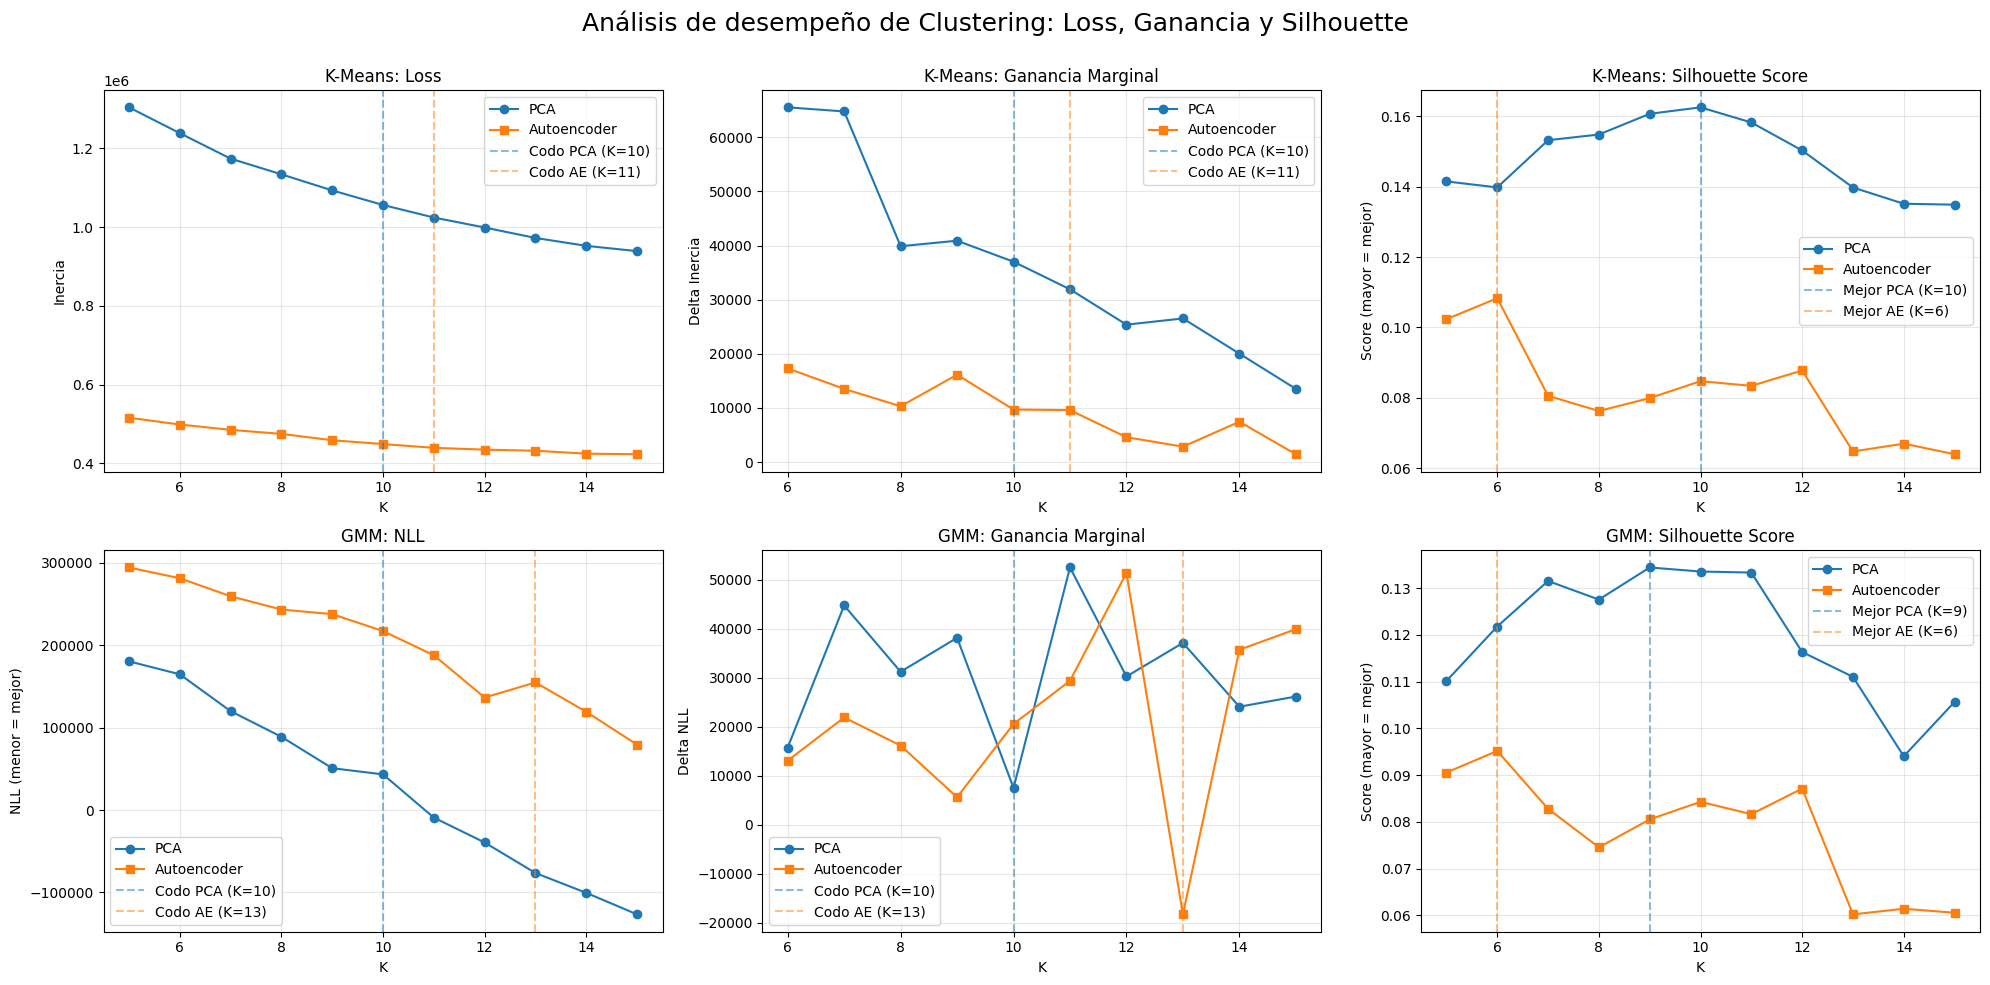

In [ ]:
k_list = list(k_values)
k_marg = list(k_values)[1:]  # eje X de la ganancia marginal (arranca en K=6)

marginal_gain_pca_kmeans = [losses_pca_kmeans[i] - losses_pca_kmeans[i+1] for i in range(len(losses_pca_kmeans)-1)]
marginal_gain_ae_kmeans  = [losses_ae_kmeans[i]  - losses_ae_kmeans[i+1]  for i in range(len(losses_ae_kmeans)-1)]

nll_pca = [-ll for ll in log_likelihood_pca]
nll_ae  = [-ll for ll in log_likelihood_ae]
marginal_gain_pca_gmm = [nll_pca[i] - nll_pca[i+1] for i in range(len(nll_pca)-1)]
marginal_gain_ae_gmm  = [nll_ae[i]  - nll_ae[i+1]  for i in range(len(nll_ae)-1)]

silhouette_pca_kmeans = [silhouette_score(X_pca_3k, labels_pca_dict_kmeans[k]) for k in k_values]
silhouette_ae_kmeans  = [silhouette_score(X_ae_3k,  labels_ae_dict_kmeans[k])  for k in k_values]
silhouette_pca_gmm    = [silhouette_score(X_pca_3k, labels_pca_dict_gmm[k])    for k in k_values]
silhouette_ae_gmm     = [silhouette_score(X_ae_3k,  labels_ae_dict_gmm[k])     for k in k_values]

k_elbow_pca_kmeans, _ = find_elbow_point(k_list, losses_pca_kmeans)
k_elbow_ae_kmeans,  _ = find_elbow_point(k_list, losses_ae_kmeans)
k_elbow_pca_gmm,    _ = find_elbow_point(k_list, nll_pca)
k_elbow_ae_gmm,     _ = find_elbow_point(k_list, nll_ae)

k_sil_pca_kmeans = k_list[int(np.argmax(silhouette_pca_kmeans))]
k_sil_ae_kmeans  = k_list[int(np.argmax(silhouette_ae_kmeans))]
k_sil_pca_gmm    = k_list[int(np.argmax(silhouette_pca_gmm))]
k_sil_ae_gmm     = k_list[int(np.argmax(silhouette_ae_gmm))]


fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Análisis de desempeño de Clustering: Loss, Ganancia y Silhouette', fontsize=18)

def vline(ax, k, color, label):
    ax.axvline(x=k, color=color, linestyle='--', alpha=0.5, label=label)

# K-MEANS
# Loss
axes[0,0].plot(k_list, losses_pca_kmeans, marker='o', label='PCA')
axes[0,0].plot(k_list, losses_ae_kmeans,  marker='s', label='Autoencoder')
vline(axes[0,0], k_elbow_pca_kmeans, 'tab:blue',   f'Codo PCA (K={k_elbow_pca_kmeans})')
vline(axes[0,0], k_elbow_ae_kmeans,  'tab:orange', f'Codo AE (K={k_elbow_ae_kmeans})')
axes[0,0].set(title='K-Means: Loss', xlabel='K', ylabel='Inercia')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Ganancia marginal
axes[0,1].plot(k_marg, marginal_gain_pca_kmeans, marker='o', label='PCA')
axes[0,1].plot(k_marg, marginal_gain_ae_kmeans,  marker='s', label='Autoencoder')
vline(axes[0,1], k_elbow_pca_kmeans, 'tab:blue',   f'Codo PCA (K={k_elbow_pca_kmeans})')
vline(axes[0,1], k_elbow_ae_kmeans,  'tab:orange', f'Codo AE (K={k_elbow_ae_kmeans})')
axes[0,1].set(title='K-Means: Ganancia Marginal', xlabel='K', ylabel='Delta Inercia')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Silhouette
axes[0,2].plot(k_list, silhouette_pca_kmeans, marker='o', label='PCA')
axes[0,2].plot(k_list, silhouette_ae_kmeans,  marker='s', label='Autoencoder')
vline(axes[0,2], k_sil_pca_kmeans, 'tab:blue',   f'Mejor PCA (K={k_sil_pca_kmeans})')
vline(axes[0,2], k_sil_ae_kmeans,  'tab:orange', f'Mejor AE (K={k_sil_ae_kmeans})')
axes[0,2].set(title='K-Means: Silhouette Score', xlabel='K', ylabel='Score (mayor = mejor)')
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

# GMM 
# NLL 
axes[1,0].plot(k_list, nll_pca, marker='o', label='PCA')
axes[1,0].plot(k_list, nll_ae,  marker='s', label='Autoencoder')
vline(axes[1,0], k_elbow_pca_gmm, 'tab:blue',   f'Codo PCA (K={k_elbow_pca_gmm})')
vline(axes[1,0], k_elbow_ae_gmm,  'tab:orange', f'Codo AE (K={k_elbow_ae_gmm})')
axes[1,0].set(title='GMM: NLL', xlabel='K', ylabel='NLL (menor = mejor)')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# Ganancia marginal 
axes[1,1].plot(k_marg, marginal_gain_pca_gmm, marker='o', label='PCA')
axes[1,1].plot(k_marg, marginal_gain_ae_gmm,  marker='s', label='Autoencoder')
vline(axes[1,1], k_elbow_pca_gmm, 'tab:blue',   f'Codo PCA (K={k_elbow_pca_gmm})')
vline(axes[1,1], k_elbow_ae_gmm,  'tab:orange', f'Codo AE (K={k_elbow_ae_gmm})')
axes[1,1].set(title='GMM: Ganancia Marginal', xlabel='K', ylabel='Delta NLL')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# Silhouette
axes[1,2].plot(k_list, silhouette_pca_gmm, marker='o', label='PCA')
axes[1,2].plot(k_list, silhouette_ae_gmm,  marker='s', label='Autoencoder')
vline(axes[1,2], k_sil_pca_gmm, 'tab:blue',   f'Mejor PCA (K={k_sil_pca_gmm})')
vline(axes[1,2], k_sil_ae_gmm,  'tab:orange', f'Mejor AE (K={k_sil_ae_gmm})')
axes[1,2].set(title='GMM: Silhouette Score', xlabel='K', ylabel='Score (mayor = mejor)')
axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

A partir de las curvas se observa que los dos criterios no siempre coinciden, por lo que la elección de K surge de leerlos en conjunto. En el espacio de PCA, la ganancia marginal de K-Means se aplana alrededor de K≈10 y el silhouette alcanza su máximo en K=10 (K=9 para GMM), señales consistentes que apuntan a unos 9-10 grupos naturales. En el espacio del autoencoder, en cambio, ambos algoritmos ubican el mejor silhouette en K=6, indicando una estructura con menos grupos diferenciables. Cabe aclarar que para GMM la ganancia marginal resulta demasiado ruidosa entre valores consecutivos de K como para leer un codo confiable, por lo que la decisión se apoya principalmente en el silhouette. En cuanto a la relación con las clases reales, el dataset tiene 10 clases, número que el espacio de PCA recupera de forma aproximada (K≈9-10) pero que el autoencoder tiende a comprimir hacia K≈6. Esto es esperable: el clustering no supervisado agrupa por similitud geométrica en el espacio latente y no por la etiqueta semántica, de modo que clases visualmente parecidas (por ejemplo las prendas de torso como pullover, coat y shirt, o los distintos tipos de calzado) tienden a fundirse en un mismo cluster en lugar de separarse. Por lo tanto, no debe esperarse una correspondencia exacta entre el K óptimo y el número de clases, y la diferencia entre PCA y AE refleja cuánto preserva cada representación la separabilidad de esas clases solapadas.

### T-SNE

In [99]:
X_pca_scaled = X_pca_3k / np.max(np.abs(X_pca_3k))
X_tsne_2d = tsne(X_pca_scaled, max_iter=500)

t-SNE: Iniciando Descenso de Gradiente (500 iteraciones)...
Iteración 50: Error (KL Divergence) = 15.2261
Iteración 100: Error (KL Divergence) = 15.3045
Iteración 150: Error (KL Divergence) = 1.5166
Iteración 200: Error (KL Divergence) = 1.2581
Iteración 250: Error (KL Divergence) = 1.1485
Iteración 300: Error (KL Divergence) = 1.0893
Iteración 350: Error (KL Divergence) = 1.0531
Iteración 400: Error (KL Divergence) = 1.0291
Iteración 450: Error (KL Divergence) = 1.0122
Iteración 500: Error (KL Divergence) = 0.9997


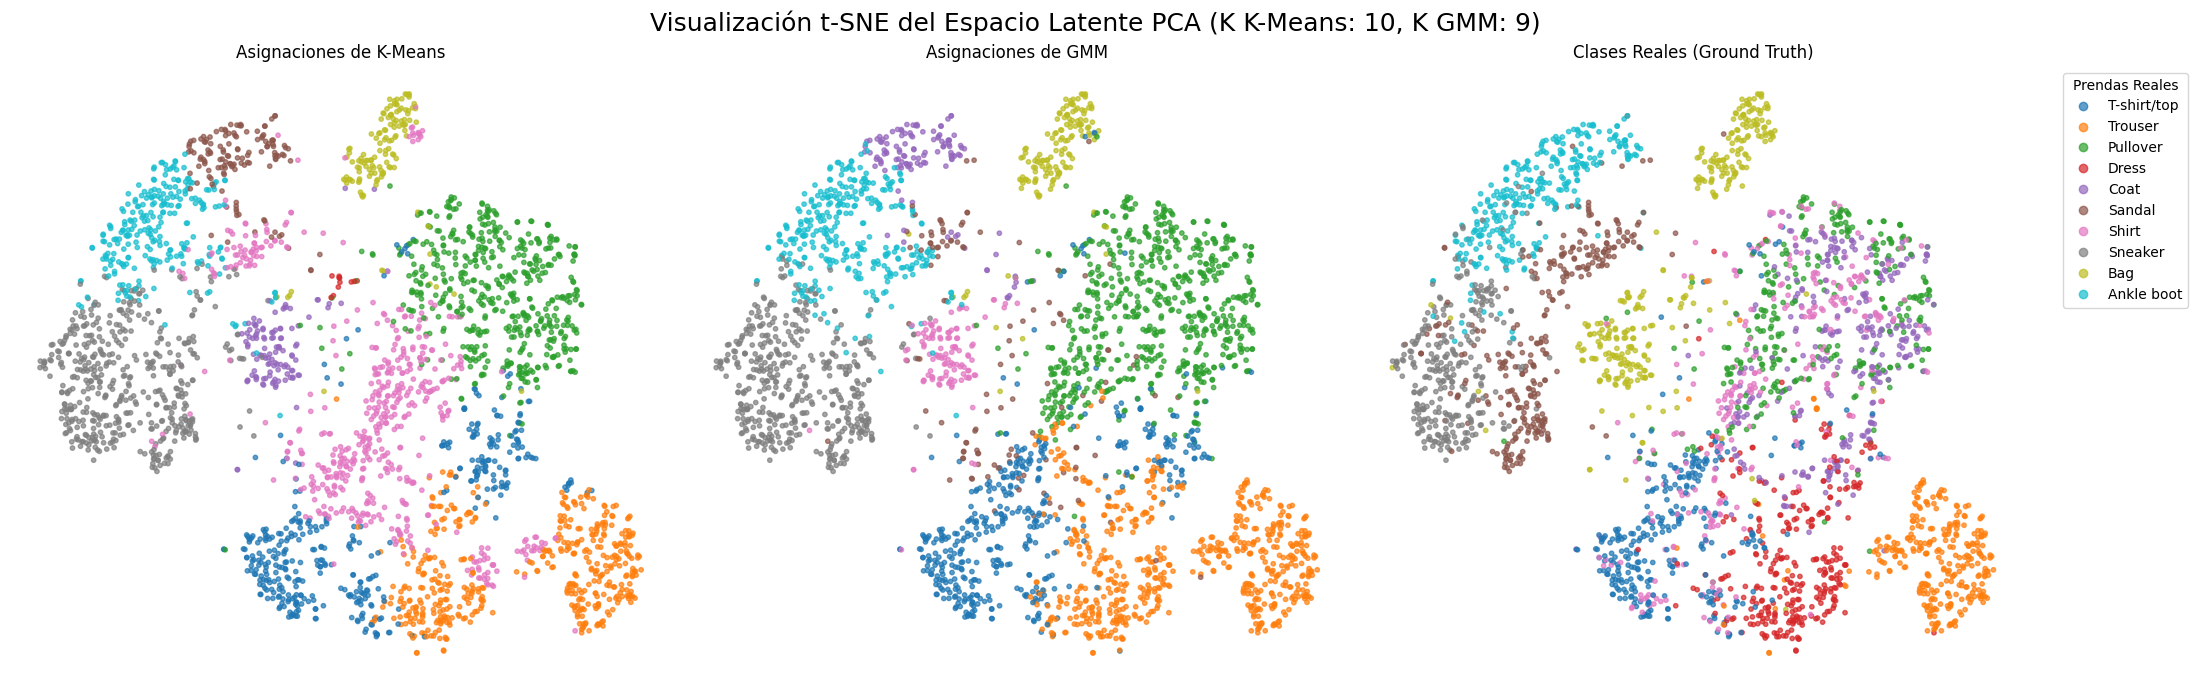

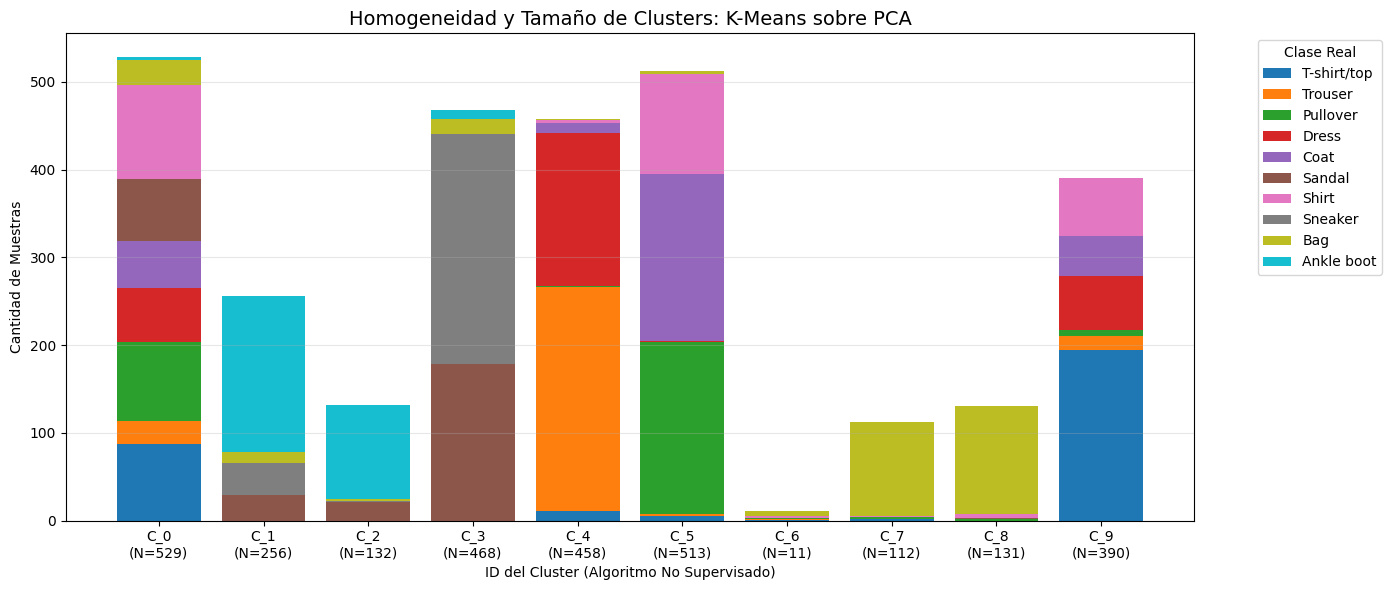

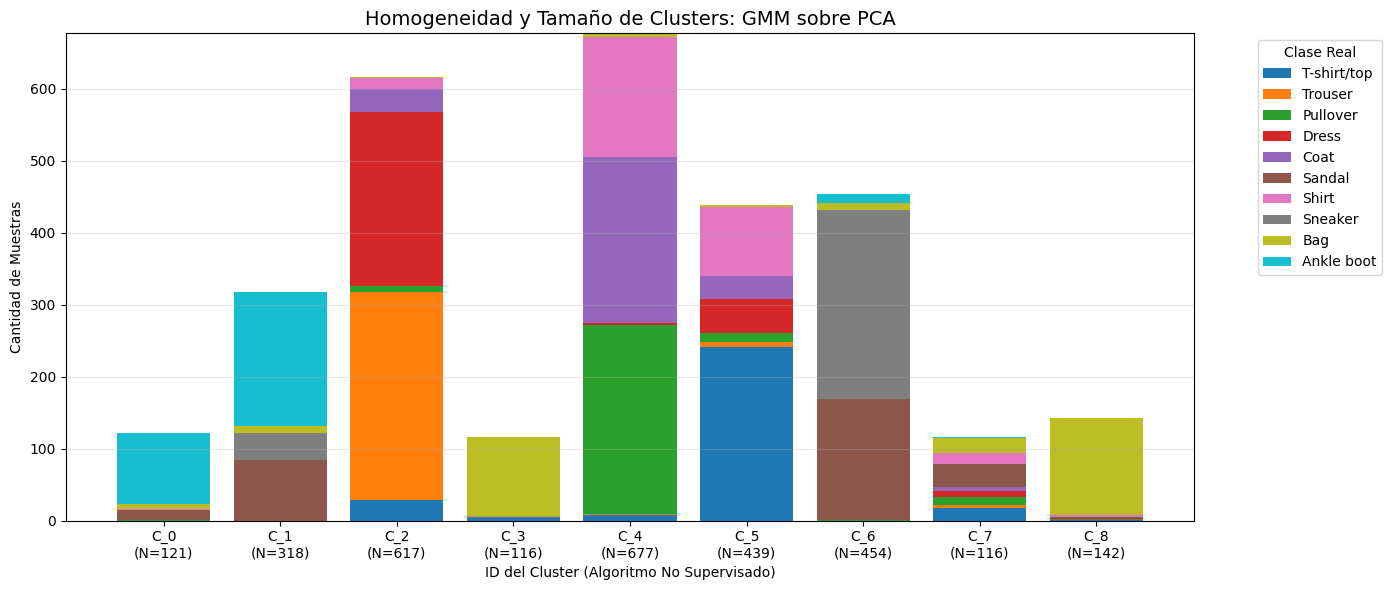

In [145]:
best_k_kmeans = 10   # mejor silhouette K-Means PCA
best_k_gmm    = 9    # mejor silhouette GMM PCA

labels_opt_kmeans = labels_pca_dict_kmeans[best_k_kmeans]
labels_opt_gmm    = labels_pca_dict_gmm[best_k_gmm]


true_labels = y_pca_3k # Las clases reales de la muestra
labels_kmeans_aligned = align_clusters_to_classes(labels_opt_kmeans, true_labels)
labels_gmm_aligned    = align_clusters_to_classes(labels_opt_gmm, true_labels)

# Nombres de las clases de Fashion MNIST para el grafico
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'Visualización t-SNE del Espacio Latente PCA (K K-Means: {best_k_kmeans}, K GMM: {best_k_gmm})', fontsize=18)

# K-Means
scatter_k = axes[0].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_kmeans_aligned, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('Asignaciones de K-Means')
axes[0].axis('off')

# GMM
scatter_g = axes[1].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_gmm_aligned, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('Asignaciones de GMM')
axes[1].axis('off')

# Clases reales
scatter_t = axes[2].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=true_labels, cmap='tab10', s=10, alpha=0.7)
axes[2].set_title('Clases Reales (Ground Truth)')
axes[2].axis('off')

axes[2].legend(handles=scatter_t.legend_elements()[0], labels=class_names,
               title="Prendas Reales", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.subplots_adjust(top=0.90) 
plt.show()

plot_cluster_quality(labels_opt_kmeans, true_labels, "K-Means sobre PCA", best_k_kmeans, class_names)
plot_cluster_quality(labels_opt_gmm, true_labels, "GMM sobre PCA", best_k_gmm, class_names)

Los gráficos muestran que la calidad de los clusters es heterogénea y depende fuertemente de qué clase representan. Tanto en el t-SNE como en las barras de composición se distinguen dos grupos. Por un lado, los clusters de alta homogeneidad, dominados por una única clase real: el calzado (Sneaker en C_3, Ankle boot en C_1 y C_2, Sandal en C_3) y los accesorios y prendas distintivas (Bag en C_7 y C_8, Trouser en C_4) forman clusters limpios y bien separados, coherentes con las islas aisladas que se observan en el t-SNE, ya que son prendas visualmente características. Por otro lado, los clusters de baja homogeneidad, donde se mezclan varias clases: las prendas de torso (T-shirt/top, Pullover, Dress, Coat y Shirt) caen en clusters sin una clase claramente dominante (C_0, C_5 y C_9 en K-Means; C_2 y C_4 en GMM), lo que refleja que son visualmente parecidas entre sí y que el clustering no logra separarlas en el espacio latente de PCA. Esto se confirma en el t-SNE, donde esas clases ocupan una región central solapada en lugar de grupos definidos. En cuanto a la cantidad de muestras, los clusters no tienen tamaños uniformes: varios superan los 500 puntos mientras que el cluster C_6 de K-Means queda casi degenerado (N=11), señal de que K=10 es ligeramente superior a la cantidad de grupos que la estructura natural de los datos soporta. Además, algunas clases fáciles se subdividen en más de un cluster (por ejemplo Ankle boot aparece como mayoritaria en C_1 y C_2, y Bag en C_7 y C_8), lo que indica que no todos los clusters adicionales capturan una clase nueva sino que a veces solo parten en dos una clase ya bien identificada. En conjunto, el número de clusters verdaderamente homogéneos es menor que 10, lo que explica por qué los criterios de selección de K (en particular el silhouette del autoencoder) tendían a sugerir valores más bajos que la cantidad real de clases.